In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df_sample = pd.read_csv("data/adv_sample_225000.csv")

In [3]:
df_sample.shape

(225000, 90)

In [4]:
df_sample["label"].value_counts()

label
BENIGN            75000
DoS_ATTACK        75000
NON_DoS_ATTACK    75000
Name: count, dtype: int64

In [5]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [7]:
X_min_raw = X.min(axis=0).values
X_max_raw = X.max(axis=0).values
X_min_df = pd.DataFrame([X_min_raw], columns=X.columns)
X_max_df = pd.DataFrame([X_max_raw], columns=X.columns)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_full = scaler.transform(X)
X_min_scaled = scaler.transform(X_min_df).flatten()
X_max_scaled = scaler.transform(X_max_df).flatten()
x_min_t = torch.tensor(X_min_scaled, dtype=torch.float32, device=device)
x_max_t = torch.tensor(X_max_scaled, dtype=torch.float32, device=device)

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)
X_full_tensor = torch.tensor(X_full, dtype=torch.float32)
y_full_tensor = torch.tensor(y.values, dtype=torch.long)

In [9]:
input_size = X.shape[1]
hidden_size = 128
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [10]:
model = MultiClassDNN(input_size=input_size).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [11]:
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.5233, Val Loss: 0.3772
Epoch 2, Train Loss: 0.3753, Val Loss: 0.3675
Epoch 3, Train Loss: 0.3692, Val Loss: 0.3647
Epoch 4, Train Loss: 0.3668, Val Loss: 0.3631
Epoch 5, Train Loss: 0.3648, Val Loss: 0.3623
Epoch 6, Train Loss: 0.3634, Val Loss: 0.3614
Epoch 7, Train Loss: 0.3626, Val Loss: 0.3614
Epoch 8, Train Loss: 0.3619, Val Loss: 0.3615
Epoch 9, Train Loss: 0.3614, Val Loss: 0.3597
Epoch 10, Train Loss: 0.3605, Val Loss: 0.3598
Epoch 11, Train Loss: 0.3605, Val Loss: 0.3590
Epoch 12, Train Loss: 0.3596, Val Loss: 0.3590
Epoch 13, Train Loss: 0.3592, Val Loss: 0.3589
Epoch 14, Train Loss: 0.3593, Val Loss: 0.3589
Epoch 15, Train Loss: 0.3596, Val Loss: 0.3589
Epoch 16, Train Loss: 0.3593, Val Loss: 0.3586
Epoch 17, Train Loss: 0.3586, Val Loss: 0.3580
Epoch 18, Train Loss: 0.3584, Val Loss: 0.3577
Epoch 19, Train Loss: 0.3581, Val Loss: 0.3580
Epoch 20, Train Loss: 0.3577, Val Loss: 0.3579
Epoch 21, Train Loss: 0.3578, Val Loss: 0.3579
Epoch 22, Train Loss: 

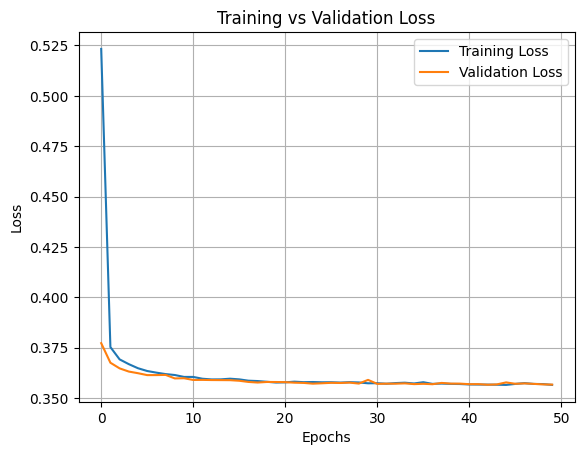

In [12]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [13]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

In [14]:
cols = list(X.columns)
cont_idx   = list(range(len(cols)))
bin_idx    = []
cat_groups = []  
_Xv = X.to_numpy(dtype=float)
int_idx = [i for i in range(len(cols)) if np.allclose(_Xv[:, i], np.round(_Xv[:, i]), equal_nan=True)]

In [15]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8900148148148148
Weighted F1: 0.8899537375060568
Macro F1: 0.8899537375060568
ROC-AUC: 0.9721698586008232


In [16]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     22500
    DoS_ATTACK       0.82      0.85      0.84     22500
NON_DoS_ATTACK       0.85      0.82      0.83     22500

      accuracy                           0.89     67500
     macro avg       0.89      0.89      0.89     67500
  weighted avg       0.89      0.89      0.89     67500



In [17]:
def pgd_attack(model, x, y, epsilon, x_min=None, x_max=None, target_class=None, verbose=False):
    alpha = epsilon / 7
    num_steps = 100
    n_restarts = 10
    momentum = 0.9
    model.eval()
    device = next(model.parameters()).device
    if not isinstance(x, torch.Tensor): x = torch.tensor(x, dtype=torch.float32)
    if not isinstance(y, torch.Tensor): y = torch.tensor(np.array(y), dtype=torch.long)
    x = x.to(device)
    y = y.to(device)
    if x_min is not None: x_min = x_min.clone().detach().to(device=device, dtype=torch.float32)
    if x_max is not None: x_max = x_max.clone().detach().to(device=device, dtype=torch.float32)
    cont_idx_t = torch.tensor(cont_idx, device=device)
    bin_idx_t  = torch.tensor(bin_idx, device=device) if bin_idx else None
    N = x.size(0)
    num_classes = model(x[:1]).shape[1]
    best_is_fooled = torch.zeros(N, dtype=torch.bool, device=device)
    best_loss      = torch.full((N,), -float("inf"), device=device)
    best_x_adv     = x.clone()
    for restart in range(n_restarts):
        delta = torch.zeros_like(x)
        if restart == 0:
            pass
        elif restart % 3 == 1:
            delta[:, cont_idx] = torch.empty(N, len(cont_idx), device=device).uniform_(-epsilon, epsilon)
        else:
            with torch.no_grad():
                init_logits = model(x)
                masked = init_logits.clone()
                masked.scatter_(1, y.unsqueeze(1), -1e9)
                second_class = masked.argmax(dim=1)
            x_tmp = x.detach().requires_grad_(True)
            guide_loss = F.cross_entropy(model(x_tmp), second_class)
            guide_loss.backward()
            with torch.no_grad():
                g = x_tmp.grad.detach()
                delta[:, cont_idx_t] = -epsilon * torch.sign(g[:, cont_idx_t])  # descend CE toward second_class
        x_adv = (x + delta)
        if x_min is not None and x_max is not None:
            x_adv = torch.clamp(x_adv, x_min, x_max)
        x_adv = x_adv.clone()
        loss_type = restart % 3  # 0=CE, 1=CW, 2=DLR
        with torch.no_grad():
            tgt_logits = model(x_adv)
            tgt_masked = tgt_logits.clone()
            tgt_masked.scatter_(1, y.unsqueeze(1), -1e9)
            sorted_wrong = tgt_masked.argsort(dim=1, descending=True)
            target_vec = sorted_wrong[:, restart % (num_classes - 1)]
        grad_momentum = torch.zeros_like(x)
        still_alive = torch.ones(N, dtype=torch.bool, device=device)
        for step in range(num_steps):
            if still_alive.sum() == 0: break
            x_adv_alive = x_adv[still_alive].detach().requires_grad_(True)
            y_alive = y[still_alive]
            logits = model(x_adv_alive)
            if target_class is not None:
                t = torch.full_like(y_alive, target_class)
                if loss_type == 1:  # CW: maximize target logit over correct logit
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    target_logit  = logits.gather(1, t.unsqueeze(1)).squeeze(1)
                    loss = (target_logit - correct_logit).mean()
                elif loss_type == 2:  # DLR: normalized logit difference
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    target_logit  = logits.gather(1, t.unsqueeze(1)).squeeze(1)
                    top2 = logits.topk(2, dim=1).values
                    denom = (top2[:, 0] - top2[:, 1]).abs().clamp(min=1e-6)
                    loss = ((target_logit - correct_logit) / denom).mean()
                else:  # CE: push toward target class
                    loss = -F.cross_entropy(logits, t)
            else:
                tv = target_vec[still_alive]
                if loss_type == 1:  # CW: maximize wrong class logit over correct
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    target_logit  = logits.gather(1, tv.unsqueeze(1)).squeeze(1)
                    loss = (target_logit - correct_logit).mean()
                elif loss_type == 2:  # DLR: normalized, uses top-3 for stability
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    is_top = (logits.argmax(dim=1) == y_alive)
                    top2_vals = logits.topk(2, dim=1).values
                    second_best = torch.where(is_top, top2_vals[:, 1], top2_vals[:, 0])
                    sorted_logits = logits.sort(dim=1, descending=True).values
                    denom = (sorted_logits[:, 0] - sorted_logits[:, 2]).abs().clamp(min=1e-6)
                    loss = ((second_best - correct_logit) / denom).mean()
                else:  # CE: maximize loss on true class
                    loss = F.cross_entropy(logits, y_alive)
            model.zero_grad(set_to_none=True)
            loss.backward()
            raw_grad = x_adv_alive.grad.detach()
            l1_norm = raw_grad.abs().sum(dim=1, keepdim=True).clamp(min=1e-12)
            grad_momentum[still_alive] = (momentum * grad_momentum[still_alive] + raw_grad / l1_norm)
            grad_sign = torch.sign(grad_momentum[still_alive])
            alpha_t = alpha * (0.3 + 0.7 * (1 + math.cos(math.pi * step / num_steps)) / 2)
            x_adv_step = x_adv[still_alive].detach()
            x_adv_step[:, cont_idx_t] = x_adv_step[:, cont_idx_t] + alpha_t * grad_sign[:, cont_idx_t]
            x_adv_step[:, cont_idx_t] = torch.max(
                torch.min(x_adv_step[:, cont_idx_t],
                          torch.min(x[:, cont_idx_t][still_alive] + epsilon, x_max_t[cont_idx_t].unsqueeze(0))),
                torch.max(x[:, cont_idx_t][still_alive] - epsilon, x_min_t[cont_idx_t].unsqueeze(0)))
            if bin_idx_t is not None and len(bin_idx) > 0:
                flip_mask = grad_sign[:, bin_idx_t] > 0
                x_adv_step[:, bin_idx_t] = torch.where(flip_mask,
                    torch.ones_like(x_adv_step[:, bin_idx_t]),
                    torch.zeros_like(x_adv_step[:, bin_idx_t]))
                x_adv_step[:, bin_idx_t] = torch.clamp(x_adv_step[:, bin_idx_t], x_min_t[bin_idx_t], x_max_t[bin_idx_t])
            if cat_groups is not None:
                for group in cat_groups:
                    logits_cat = x_adv_step[:, group] + alpha_t * grad_sign[:, group]
                    best_cat = torch.argmax(logits_cat, dim=1)
                    one_hot = torch.zeros_like(logits_cat)
                    one_hot[torch.arange(still_alive.sum()), best_cat] = 1.0
                    x_adv_step[:, group] = one_hot
                    valid = ((x_min_t[group] <= x_adv_step[:, group]) & (x_adv_step[:, group] <= x_max_t[group])).all(dim=1, keepdim=True)
                    x_adv_step[:, group] = torch.where(valid.expand_as(x_adv_step[:, group]), x_adv_step[:, group], x[still_alive][:, group])
            if x_min is not None and x_max is not None:
                x_adv_step = torch.clamp(x_adv_step, x_min, x_max)
            x_adv[still_alive] = x_adv_step
            with torch.no_grad():
                preds_alive = model(x_adv[still_alive]).argmax(dim=1)
                newly_fooled = still_alive.clone()
                newly_fooled[still_alive] = (preds_alive != y[still_alive])
                still_alive[newly_fooled] = False
        with torch.no_grad():
            logits_final = model(x_adv)
            preds_final  = logits_final.argmax(dim=1)
            fooled_now   = (preds_final != y)
            if target_class is not None:
                per_loss = -F.cross_entropy(logits_final,
                    torch.full_like(y, target_class), reduction="none")
            else:
                per_loss = F.cross_entropy(logits_final, y, reduction="none")
        update_mask = (
            (fooled_now & ~best_is_fooled)
            | (fooled_now & best_is_fooled & (per_loss > best_loss))
            | (~fooled_now & ~best_is_fooled & (per_loss > best_loss))
        )
        best_is_fooled = torch.where(update_mask, fooled_now, best_is_fooled)
        best_loss = torch.where(update_mask, per_loss, best_loss)
        best_x_adv = torch.where(update_mask.unsqueeze(1).expand_as(x_adv), x_adv, best_x_adv)
        if verbose:
            fool_rate = fooled_now.float().mean().item()
            loss_name = ["CE", "CW", "DLR"][loss_type]
            print(f"  Restart {restart+1}/{n_restarts} | α={alpha_t:.4f} | "
                  f"loss={loss_name} | "
                  f"fool_rate={fool_rate:.3f} | "
                  f"cumulative_fool={best_is_fooled.float().mean():.3f}")
    return best_x_adv.detach()

In [18]:
def epsilon_eval(model, X_full_tensor, y_full_tensor, epsilon, verbose=True, x_min=None, x_max=None):
    x_adv_scaled = pgd_attack(model, X_full_tensor, y_full_tensor, epsilon, x_min=x_min, x_max=x_max)
    x_adv_raw = scaler.inverse_transform(pd.DataFrame(x_adv_scaled.cpu().numpy(), columns=X.columns))
    if int_idx:
        x_adv_raw[:, int_idx] = np.round(x_adv_raw[:, int_idx])
    x_adv_raw = np.clip(x_adv_raw, X_min_raw, X_max_raw)
    x_adv_eval = torch.tensor(scaler.transform(pd.DataFrame(x_adv_raw, columns=X.columns)), dtype=torch.float32, device=device)
    model.eval()
    with torch.no_grad():
        y_pred_clean = model(X_full_tensor.to(device)).argmax(1).cpu().numpy()
        y_pred       = model(x_adv_eval).argmax(1).cpu().numpy()
    y_true = y_full_tensor.cpu().numpy()
    correct_clean      = (y_pred_clean == y_true)
    successful_attacks = (y_pred != y_true) & correct_clean
    asr = successful_attacks.sum() / max(correct_clean.sum(), 1)
    int_names = [X.columns[i] for i in int_idx]
    full_adv_df = pd.DataFrame(x_adv_raw, columns=X.columns)
    if int_names:
        full_adv_df[int_names] = full_adv_df[int_names].round(0).astype("int64")
    full_adv_df["true_label"] = y_true
    full_adv_df["y_pred"]     = y_pred
    full_filename = f"data/adversarial_full_epsilon_{epsilon}.csv"
    full_adv_df.to_csv(full_filename, index=False)
    adv_df = full_adv_df.copy()
    adv_df["pred_clean"] = y_pred_clean
    adv_df = adv_df[successful_attacks & (y_true != 0)].reset_index(drop=True)
    n_filtered = len(adv_df)
    if n_filtered:
        min_count = adv_df["true_label"].value_counts().min()
        adv_df = (adv_df.groupby("true_label", group_keys=False).apply(lambda g: g.sample(min_count, random_state=42), include_groups=False).reset_index(drop=True))
        adv_df.to_csv(f"data/adversarial_epsilon_{epsilon}.csv", index=False)
    clean_acc, adv_acc = accuracy_score(y_true, y_pred_clean), accuracy_score(y_true, y_pred)
    print(f"[eps={epsilon}] exported {len(full_adv_df):,} rows -> {full_filename} | "
          f"DNN clean {clean_acc:.4f} -> adv {adv_acc:.4f} | ASR {asr*100:.1f}% | "
          f"successful-attack rows {len(adv_df):,} (of {n_filtered:,} pre-balance)")
    if verbose:
        print(classification_report(y_true, y_pred, digits=4))
    return {"epsilon": epsilon, "clean_accuracy": clean_acc, "adv_accuracy": adv_acc, "asr": asr}

In [19]:
results = []
for epsilon in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 2, 5, 20]:
    results.append(epsilon_eval(model, X_full_tensor, y_full_tensor, epsilon, x_min=x_min_t, x_max=x_max_t))

[eps=0.01] exported 225,000 rows -> data/adversarial_full_epsilon_0.01.csv | DNN clean 0.8905 -> adv 0.8895 | ASR 0.1% | successful-attack rows 210 (of 238 pre-balance)
              precision    recall  f1-score   support

           0     0.9991    1.0000    0.9996     75000
           1     0.8239    0.8505    0.8370     75000
           2     0.8459    0.8179    0.8317     75000

    accuracy                         0.8895    225000
   macro avg     0.8897    0.8895    0.8894    225000
weighted avg     0.8897    0.8895    0.8894    225000

[eps=0.05] exported 225,000 rows -> data/adversarial_full_epsilon_0.05.csv | DNN clean 0.8905 -> adv 0.8728 | ASR 2.0% | successful-attack rows 1,576 (of 3,816 pre-balance)
              precision    recall  f1-score   support

           0     0.9989    0.9977    0.9983     75000
           1     0.7906    0.8418    0.8154     75000
           2     0.8317    0.7789    0.8045     75000

    accuracy                         0.8728    225000
   ma

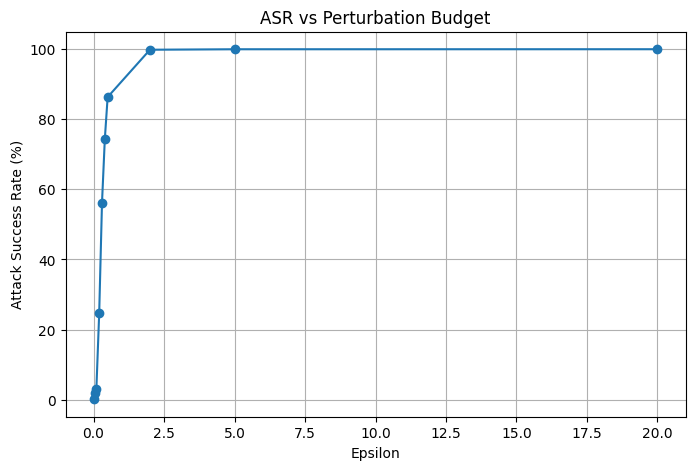

In [20]:
eps = [r["epsilon"] for r in results]
asr = [r["asr"] * 100 for r in results]

plt.figure(figsize=(8,5))
plt.plot(eps, asr, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
plt.title("ASR vs Perturbation Budget")
plt.grid(True)
plt.show()